# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [3]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(42)

In [4]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


/Users/ctn/code/tempo/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


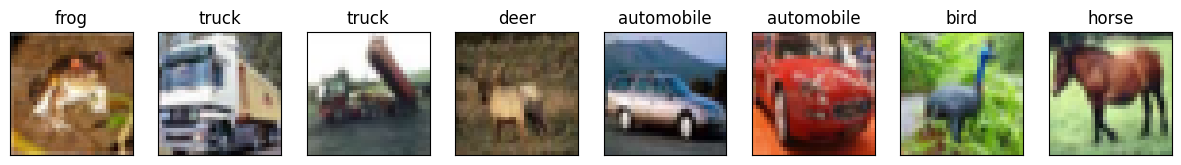

In [5]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [6]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


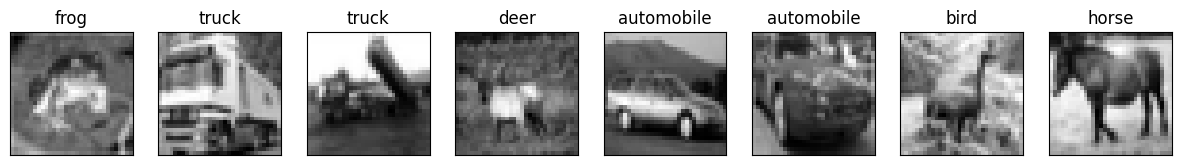

In [7]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [8]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0
x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [9]:
# Hiper-parâmetros
input_shape = 1024 # 32 x 32 x 1
epochs=20                       # https://github.com/julianweisbord/pytorch-mlp-cifar10/blob/master/mlp.py#L26
batch_size=128                  # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2
learning_rate = 0.001

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet


# Experimento 1 - Sem dropout e sem early stop

In [10]:
# Construção dos modelos da rede
model_1 = Sequential([
    Dense(256, activation='relu', input_shape=(input_shape,)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax'),
])
model_1.summary()

/Users/ctn/code/tempo/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,762 (1.26 MB)

 Trainable params: 330,762 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

model_1.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_1 = model_1.fit(
    x_train_df.values,
    y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.2595 - loss: 2.0312 - val_accuracy: 0.3030 - val_loss: 1.9428
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3284 - loss: 1.8816 - val_accuracy: 0.3254 - val_loss: 1.8658
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3546 - loss: 1.8162 - val_accuracy: 0.3470 - val_loss: 1.8254
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.3704 - loss: 1.7701 - val_accuracy: 0.3676 - val_loss: 1.7861
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3872 - loss: 1.7288 - val_accuracy: 0.3756 - val_loss: 1.7618
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.3982 - loss: 1.6966 - val_accuracy: 0.3816 - val_loss: 1.7408
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4098 - loss: 1.6654 - val_accuracy: 0.3972 - val_loss: 1.7107
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4216 - loss: 1.6378 - val

Modelo 1 Teste — loss: 1.7098, acurácia: 0.4003


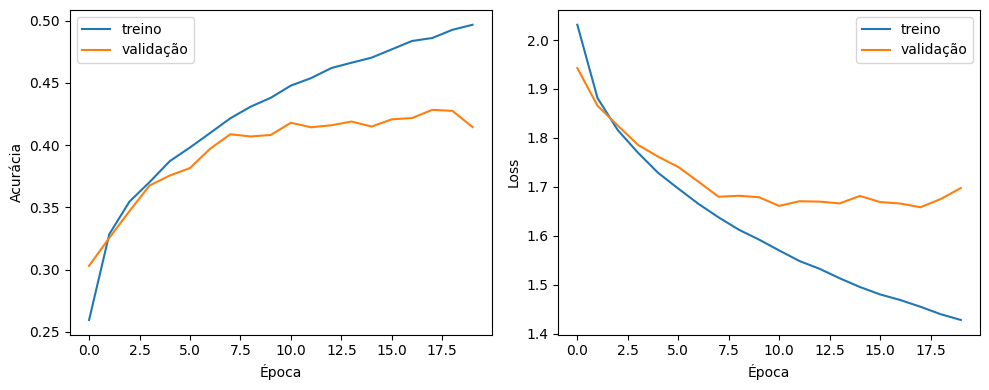

In [12]:
loss_1, acc_1 = model_1.evaluate(x_test_df.values, y_test_cat, verbose=0)
print(f'Modelo 1 Teste — loss: {loss_1:.4f}, acurácia: {acc_1:.4f}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='treino')
plt.plot(history_1.history['val_accuracy'], label='validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='treino')
plt.plot(history_1.history['val_loss'], label='validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Principal motivo observado para a val_accuracy não melhorar muito durante os testes

**Um MLP simples não extrai bem características de imagens**

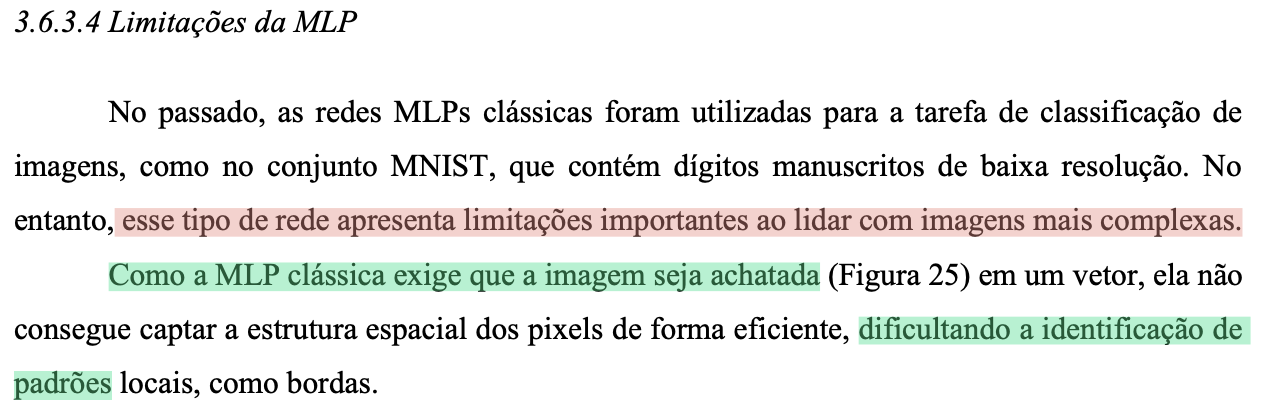

# Experimento 2 - Sem dropout e com early stop

In [13]:
# Treinamento

In [14]:
# Resutados

# Experimento 3 - Com dropout e sem early stop

In [15]:
# Treinamento

In [16]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [17]:
# Treinamento

In [18]:
# Resultados